# 06 — Sales Drivers (Regression)
**RetailMind · Data Science Practicum 2 · Sai Teja Sunku**

Quantifies what moves the needle on sales. Uses the same LightGBM model
as the forecaster — but evaluated as a regression problem with feature
importance + direction.

| Concept | Module |
|---|---|
| Walk-forward CV regression | `retailmind.regression.fit_driver_model` |
| Feature importance (gain) | LightGBM booster output |
| Direction sign | Correlation between feature and target |
| Auto log-transform for skewed targets | Built in |
| **Leakage guard** | `LEAKY_CONTEMPORANEOUS` set excludes accounting-identity columns |


In [1]:
# Common setup: make the project package importable from the notebooks/ folder
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


## 1. Fit the driver model

In [2]:
from retailmind import RetailPipeline

p = RetailPipeline.from_files('../train.csv', auxiliary_paths=['../store.csv'])
p.canonicalize_()
p.drivers_(sample_entities=50)

dr = p.driver_report
print(f'Model:        {dr.model_name}')
print(f'R²:           {dr.r2:+.3f}  (walk-forward CV, {dr.cv_folds} folds)')
print(f'RMSE:         {dr.rmse:,.1f}')
print(f'Baseline R²:  {dr.baseline_r2:+.3f}')
print(f'R² lift:      {dr.r2_lift_vs_baseline:+.3f}')

Model:        lightgbm
R²:           +0.954  (walk-forward CV, 3 folds)
RMSE:         1,376.6
Baseline R²:  -0.044
R² lift:      +0.998


## 2. Top features and direction

In [3]:
dr.importance.head(10)[['feature', 'importance', 'direction_label']]

,feature,importance,direction_label
0,is_open,1.079550e+13,↑ increases sales
1,sales_lag_14,3.171410e+12,↑ increases sales
2,sales_lag_28,8.350989e+11,↑ increases sales
3,sales_lag_1,7.324653e+11,↑ increases sales
4,promo,5.220977e+11,↑ increases sales
5,sales_rmean_14,3.618698e+11,↑ increases sales
6,sales_rmean_28,3.006267e+11,↑ increases sales
7,sales_rmean_7,2.719742e+11,↑ increases sales
8,dayofyear,2.334596e+11,≈ neutral
9,sales_rstd_7,2.160867e+11,↑ increases sales


## 3. Visualise importance

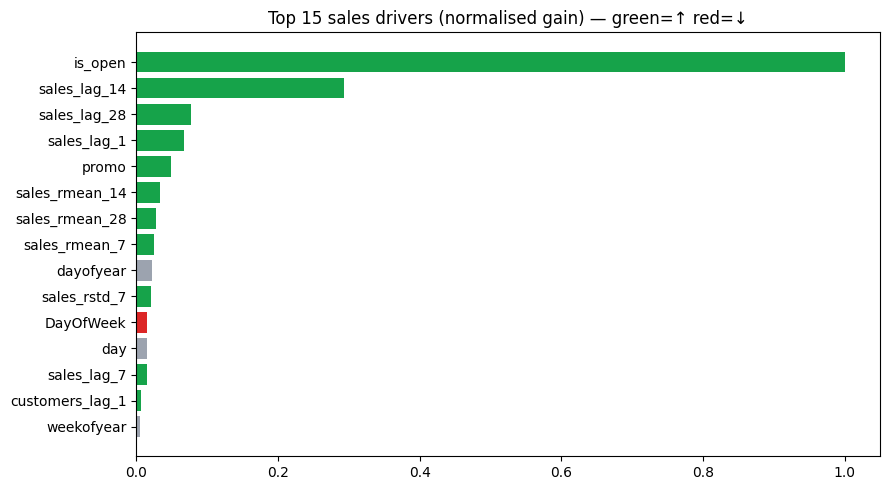

In [4]:
imp = dr.importance.head(15).copy()
imp['importance_norm'] = imp['importance'] / imp['importance'].max()
plt.figure(figsize=(9, 5))
colors = ['#16A34A' if 'increases' in l else '#DC2626' if 'decreases' in l else '#9CA3AF'
          for l in imp['direction_label']]
plt.barh(imp['feature'][::-1], imp['importance_norm'][::-1], color=colors[::-1])
plt.title('Top 15 sales drivers (normalised gain) — green=↑ red=↓')
plt.tight_layout(); plt.show()

## Summary
- `R²` alone can mislead — always paired with baseline R² + lift
- Leakage guard excludes contemporaneous accounting variables → honest results
- Direction sign helps the user understand *how* each feature moves sales

**Next:** [07 — Order Recommendations](07_order_recommendations.ipynb)
